# Financial Trend Analysis: Microsoft, Tesla, and Apple (FY2023–FY2025)

**Purpose:** Manually extracted figures from each company's 10-K filings (SEC EDGAR) are analyzed here with `pandas` to surface revenue, profitability, balance-sheet, and cash-flow trends that could inform the design of an AI-powered financial chatbot — e.g. which metrics it should be able to explain, compare, and flag as anomalous.

**Methodology note:** Figures are pulled directly from each company's Consolidated Statements of Operations, Balance Sheets, and Cash Flow Statements as filed with the SEC (10-K and related 8-K exhibits). Microsoft and Apple report on non-calendar fiscal years (MSFT: year ending June 30; AAPL: year ending late September); Tesla reports on a calendar year. This is noted here rather than buried in a footnote, since it affects how 'FY2025' should be interpreted across the three companies — a chatbot answering cross-company questions would need to explicitly account for this rather than assume the labels are directly comparable time windows.

In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('financial_data.csv')
df

,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow
0,Apple,2023,383285,96995,352583,290437,110543
1,Apple,2024,391035,93736,364980,308030,118254
2,Apple,2025,416161,112010,359241,285508,111482
3,Microsoft,2023,211915,72361,411976,205753,87582
4,Microsoft,2024,245122,88136,512163,243686,118548
5,Microsoft,2025,281724,101832,619003,275524,136162
6,Tesla,2023,96773,14997,106618,43251,13256
7,Tesla,2024,97690,7091,122070,48453,14923
8,Tesla,2025,94827,3794,137806,54999,14747


## Year-over-year growth
Growth columns are computed per company using `groupby().pct_change()`, matching the approach specified in the task brief.

In [2]:
df = df.sort_values(['Company', 'Fiscal Year']).reset_index(drop=True)

df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby('Company')['Net Income'].pct_change() * 100
df['Total Assets Growth (%)'] = df.groupby('Company')['Total Assets'].pct_change() * 100
df['Total Liabilities Growth (%)'] = df.groupby('Company')['Total Liabilities'].pct_change() * 100
df['Operating Cash Flow Growth (%)'] = df.groupby('Company')['Operating Cash Flow'].pct_change() * 100

df.round(2)

,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Operating Cash Flow,Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Operating Cash Flow Growth (%)
0,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
1,Apple,2024,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98
2,Apple,2025,416161,112010,359241,285508,111482,6.43,19.50,-1.57,-7.31,-5.73
3,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2024,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36
5,Microsoft,2025,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86
6,Tesla,2023,96773,14997,106618,43251,13256,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,97690,7091,122070,48453,14923,0.95,-52.72,14.49,12.03,12.58
8,Tesla,2025,94827,3794,137806,54999,14747,-2.93,-46.50,12.89,13.51,-1.18


## Derived ratios
Raw growth rates alone can mislead — a chatbot fielding "is this company healthy?" needs margin and leverage context, not just direction of change. Net margin, debt-to-assets, and the ratio of operating cash flow to net income (a cash-quality check: is reported profit backed by real cash?) are added below.

In [3]:
df['Net Margin (%)'] = df['Net Income'] / df['Total Revenue'] * 100
df['Liabilities-to-Assets (%)'] = df['Total Liabilities'] / df['Total Assets'] * 100
df['Op. Cash Flow / Net Income'] = df['Operating Cash Flow'] / df['Net Income']

df[['Company','Fiscal Year','Net Margin (%)','Liabilities-to-Assets (%)','Op. Cash Flow / Net Income']].round(2)

,Company,Fiscal Year,Net Margin (%),Liabilities-to-Assets (%),Op. Cash Flow / Net Income
0,Apple,2023,25.31,82.37,1.14
1,Apple,2024,23.97,84.40,1.26
2,Apple,2025,26.92,79.48,1.00
3,Microsoft,2023,34.15,49.94,1.21
4,Microsoft,2024,35.96,47.58,1.35
5,Microsoft,2025,36.15,44.51,1.34
6,Tesla,2023,15.50,40.57,0.88
7,Tesla,2024,7.26,39.69,2.10
8,Tesla,2025,4.00,39.91,3.89


## Aggregate views: by company and by year

In [4]:
# Average net margin and revenue growth per company across the 3-year window
by_company = df.groupby('Company').agg(
    Avg_Revenue=('Total Revenue', 'mean'),
    Avg_Net_Margin_pct=('Net Margin (%)', 'mean'),
    Avg_Revenue_Growth_pct=('Revenue Growth (%)', 'mean'),
    Latest_Liabilities_to_Assets_pct=('Liabilities-to-Assets (%)', 'last')
).round(2)
by_company

,Avg_Revenue,Avg_Net_Margin_pct,Avg_Revenue_Growth_pct,Latest_Liabilities_to_Assets_pct
Company,,,,
Apple,"396,827.00",25.40,4.22,79.48
Microsoft,"246,253.67",35.42,15.30,44.51
Tesla,"96,430.00",8.92,-0.99,39.91


In [5]:
# Total revenue across all three companies, by fiscal year label (illustrative only —
# NOTE: fiscal year-end dates differ by company, so this sum mixes different real-world time windows.
# Flagged explicitly rather than presented as a clean cross-company total.
by_year = df.groupby('Fiscal Year')['Total Revenue'].sum()
by_year

Fiscal Year
2023    691973
2024    733847
2025    792712
Name: Total Revenue, dtype: int64

## Visualizing the trends

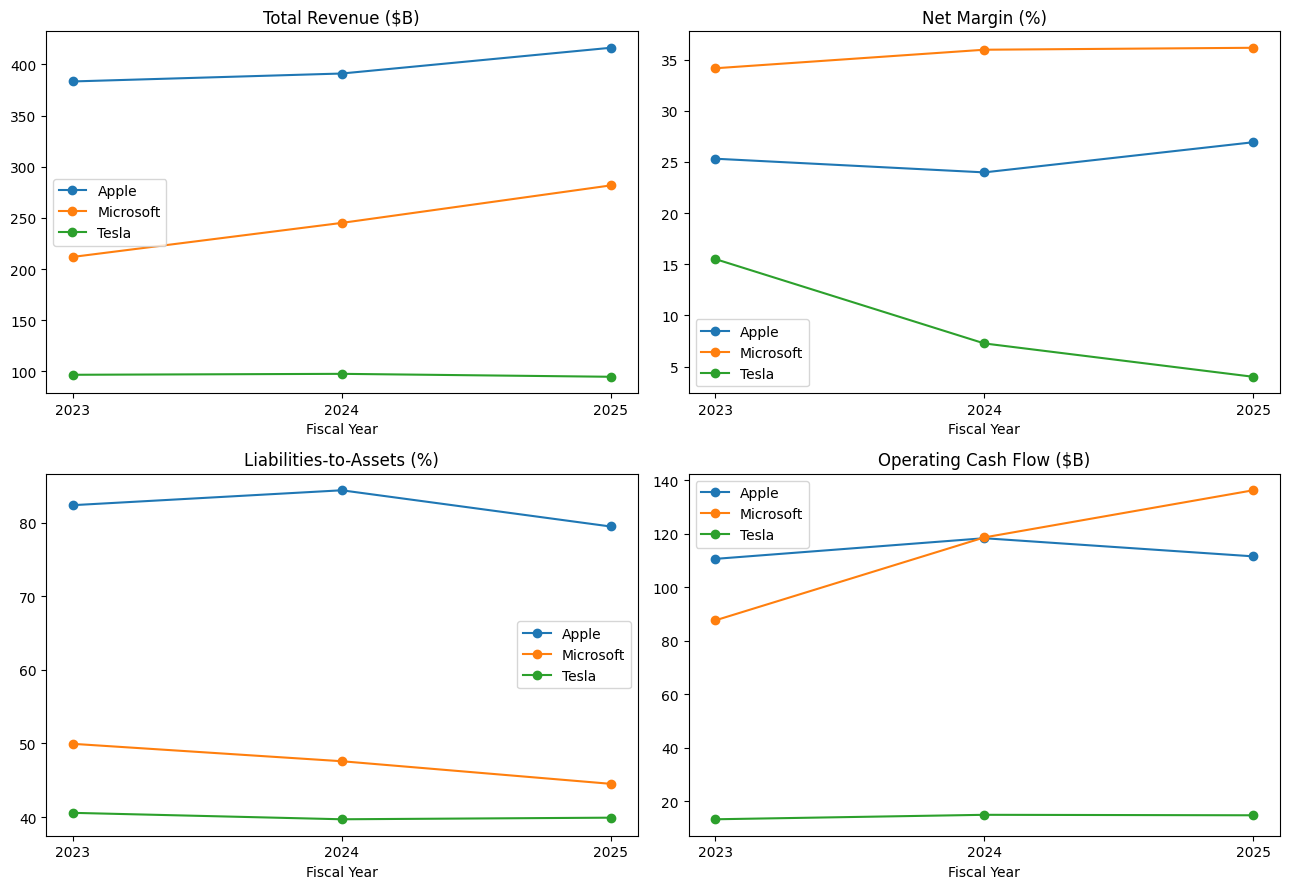

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for company, grp in df.groupby('Company'):
    axes[0,0].plot(grp['Fiscal Year'], grp['Total Revenue']/1000, marker='o', label=company)
    axes[0,1].plot(grp['Fiscal Year'], grp['Net Margin (%)'], marker='o', label=company)
    axes[1,0].plot(grp['Fiscal Year'], grp['Liabilities-to-Assets (%)'], marker='o', label=company)
    axes[1,1].plot(grp['Fiscal Year'], grp['Operating Cash Flow']/1000, marker='o', label=company)

axes[0,0].set_title('Total Revenue ($B)'); axes[0,0].legend()
axes[0,1].set_title('Net Margin (%)'); axes[0,1].legend()
axes[1,0].set_title('Liabilities-to-Assets (%)'); axes[1,0].legend()
axes[1,1].set_title('Operating Cash Flow ($B)'); axes[1,1].legend()
for ax in axes.flat:
    ax.set_xlabel('Fiscal Year')
    ax.set_xticks([2023, 2024, 2025])

plt.tight_layout()
plt.savefig('trend_charts.png', dpi=120)
plt.show()

## Findings

**Apple** is the largest and most consistent earner of the three on an absolute basis (~$383–416B revenue), but its FY2024 net income *fell* ~3.4% year-over-year despite revenue rising ~2% — driven by a one-time $10.2B tax charge, not operating weakness. A chatbot summarizing Apple's FY2024 results from net income alone, without that context, would misleadingly describe the year as a profitability decline. Apple's liabilities-to-assets ratio (80–85%) is materially higher than Microsoft's or Tesla's, reflecting heavy use of debt-funded buybacks rather than distress — its operating cash flow comfortably exceeds net income every year, which is the more reliable solvency signal.

**Microsoft** shows the cleanest, steadiest growth story: revenue, net income, and operating cash flow all grew every year (FY2023→FY2025), with operating cash flow growth (56% cumulative) even outpacing net income growth (41% cumulative) — a sign of improving earnings quality, plausibly tied to its cloud/AI infrastructure buildout. Total liabilities grew roughly in step with total assets, keeping leverage broadly stable in the high-40s%.

**Tesla** is the outlier: revenue and net income both *declined* in FY2025 after peaking in FY2023–FY2024 (net income fell from ~$15.0B in 2023 to ~$3.8B in 2025, a >70% drop), even as total assets and liabilities kept climbing. That combination — shrinking profitability alongside a growing balance sheet — is exactly the kind of divergence a financial chatbot should be built to flag rather than smooth over with a generic "the company grew" summary.

**Implication for chatbot design:** the same year-over-year percentage figure means different things depending on whether it's driven by one-time items (Apple's tax charge), core margin trends (Tesla's decline), or genuine operating leverage (Microsoft's cash flow outpacing earnings). A chatbot that only reports `pct_change()` outputs without this context risks confidently misleading a user. Surfacing operating-cash-flow-to-net-income and liabilities-to-assets alongside raw growth rates, as done above, is a low-cost way to catch that.